In [1]:
import pandas as pd
import re
import numpy as np
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pylatexenc.latexencode import unicode_to_latex as text2latex


sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats, array_stats
import random

random.seed(42)

def first_integer(s):
    for c in s:
        if c.isdigit():
            return int(c)
    return None

def get_data(fn="desc_norms_pilot.csv"):
    df = pd.read_csv(fn)
    df = df.iloc[2:]

    data_pts_wide = []

    data_pts_long = []

    for idx, row in df.iterrows():
        dist_channel = row['DistributionChannel']
        duration = row['Duration (in seconds)']
        progress = row['Progress']
        StartDate = row['StartDate']
        for i in range (1,31):
            pre = f'{i}_initial'
            post = f'{i}_post'
            qual = f'{i}_qual'
            data_pts_wide.append({
                'uid': row['ResponseId'],
                'unique_action_sit': i,
                'dist_channel': dist_channel,
                'duration': duration,
                'progress': progress,
                'StartDate': StartDate,
                'pre': row[pre],
                'post': row[post],
                'qual': row[qual]
            })


    df = pd.DataFrame(data_pts_wide)
    df = df.query("dist_channel=='anonymous'")
    df = df.dropna(subset=['pre', 'post'], how='any')
    return df


df = get_data()

# Merge with meta
meta = pd.read_csv("action_normalcy_ratings.csv")
meta['idx'] = [i+1 for i in range(len(meta))]

df = df.merge(meta, left_on='unique_action_sit', right_on='idx', how='left', suffixes=('', '_meta'), indicator=True)
df = df.rename(columns={"rating":"bot_rating"})
assert df['_merge'].unique() == ['both']

# Clean data
df['pre_clean'] = df['pre'].apply(first_integer)
df['post_clean'] = df['post'].apply(first_integer)
df['duration'] = df['duration'].astype(int)

# Make variables
df['delta'] = df['post_clean'] - df['pre_clean']
df['delta'] = df['delta'].astype(int)
df['changed_score'] = df['delta'].apply(lambda x: 1 if x != 0 else 0)

df['abs_delta'] = df['delta'].abs()

df['pre_clean_avg'] = df.groupby('unique_action_sit')['pre_clean'].transform('mean')
df['post_clean_avg'] = df.groupby('unique_action_sit')['post_clean'].transform('mean')

df['pre_abs_diff_from_avg'] = np.abs(df['pre_clean'] - df['pre_clean_avg'])

df['bot_diff_pre_i'] = df['pre_clean'] - df['bot_rating']
df['bot_diff_post_i'] = df['post_clean'] - df['bot_rating']
df['bot_diff_pre_avg'] = df['pre_clean_avg'] - df['bot_rating']
df['bot_diff_post_avg'] = df['post_clean_avg'] - df['bot_rating']

df['abs_bot_diff_pre_i'] = df['bot_diff_pre_i'].abs()
df['abs_bot_diff_post_i'] = df['bot_diff_post_i'].abs()
df['abs_bot_diff_pre_avg'] = df['bot_diff_pre_avg'].abs()
df['abs_bot_diff_post_avg'] = df['bot_diff_post_avg'].abs()

df['diff_diff'] = df['abs_bot_diff_pre_i'] - df['abs_bot_diff_post_i']

df['advisor_num'] = (df['post_clean'] - df['pre_clean'])
df['advisor_denom'] = df['bot_rating'] - df['pre_clean']

df['advisor'] = np.where(df['advisor_denom'] != 0,
                         df['advisor_num'] / df['advisor_denom'],
                         np.nan)



sd = df['abs_delta'].std()
mean = df['abs_delta'].mean()

coehen_d = mean / sd
print(f"Mean: {mean}", f"SD: {sd}", f"Cohen's d: {coehen_d}")

df['abs_delta_sds'] = df['abs_delta'] / sd

df2 = df.dropna(subset=['abs_delta_sds', 'advisor'])

array_stats(df2['advisor'].values)


FileNotFoundError: [Errno 2] No such file or directory: 'action_normalcy_ratings.csv'

In [41]:
df2.columns

Index(['uid', 'unique_action_sit', 'dist_channel', 'duration', 'progress',
       'StartDate', 'pre', 'post', 'qual', 'action', 'situation', 'is_normal',
       'bot_rating', 'condition', 'response', 'idx', '_merge', 'pre_clean',
       'post_clean', 'delta', 'changed_score', 'abs_delta', 'pre_clean_avg',
       'post_clean_avg', 'pre_abs_diff_from_avg', 'bot_diff_pre_i',
       'bot_diff_post_i', 'bot_diff_pre_avg', 'bot_diff_post_avg',
       'abs_bot_diff_pre_i', 'abs_bot_diff_post_i', 'abs_bot_diff_pre_avg',
       'abs_bot_diff_post_avg', 'diff_diff', 'advisor_num', 'advisor_denom',
       'advisor', 'abs_delta_sds'],
      dtype='object')

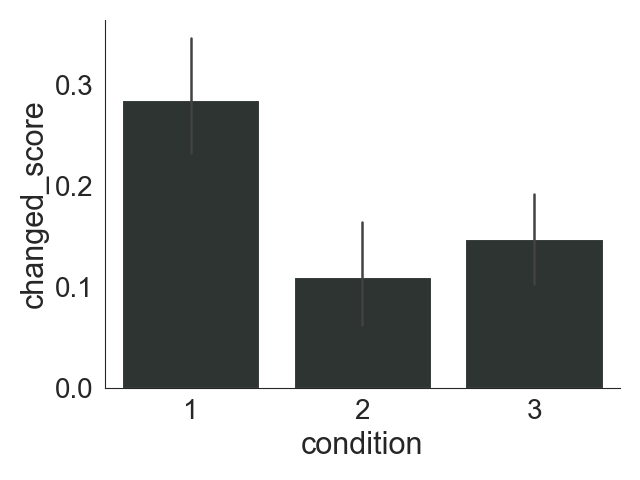

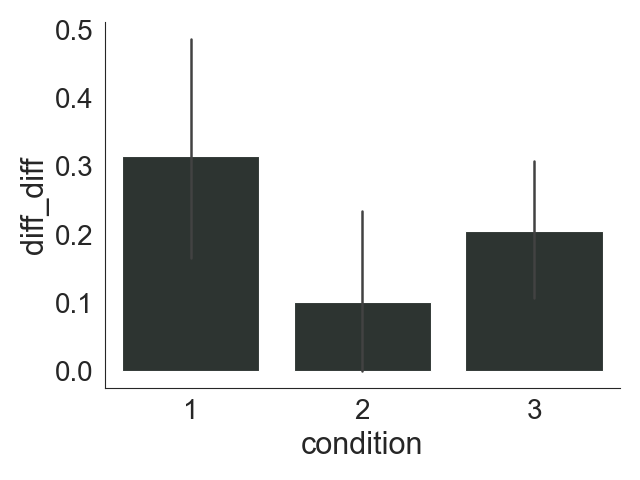

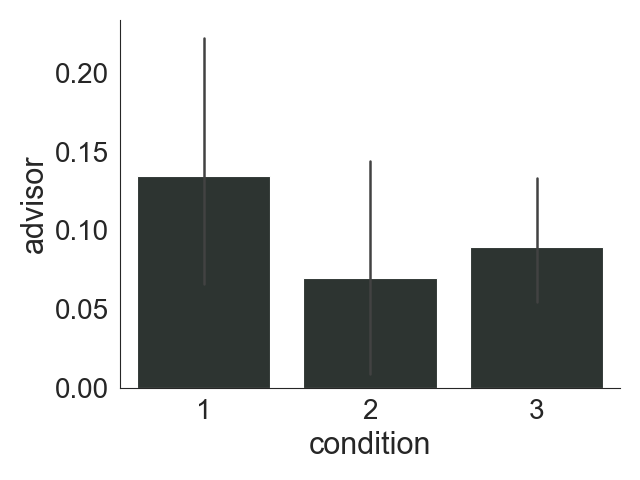

In [43]:
from src.helpers import make_aesthetic
mypal = make_aesthetic()
dvs = ['changed_score', 'diff_diff', 'advisor']
for dv in dvs:
    sns.barplot(data=df2, x='condition', y=dv)
    plt.show()

In [39]:
len(df)

634